# SINDy Quick Evaluation
Configure one system/optimizer, fit a SINDy model, and compare the simulated response with the ground truth. Edit the config cell, then run cells top-to-bottom.

In [7]:
# If pysindy is missing, uncomment the next line in a fresh runtime
# %pip install pysindy

In [1]:
import os, sys, time

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import numpy as np
import matplotlib.pyplot as plt
import pysindy as ps

sys.path.append("../utilities")
import DataGenerator as DG

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True


## Choose system and optimizer
- `SYSTEM_NAME` must match a key from `DataGenerator.model_mappings` (e.g., `lorenz`, `lorenz96`, `duffing`, `dnls_split`).
- `MODEL_ARGS` are optional positional args forwarded to the model (e.g., `(2.0, N_sites)` for DNLS variants).
- Adjust the optimizer block to try STLSQ/Lasso/Ridge/SR3 with your own hyperparameters.

In [6]:
# System configuration
SYSTEM_NAME = "dnls_split"  
STATE_DIM = 20                # For dnls_split use 2 * N_sites. 
MODEL_ARGS = (2.0, STATE_DIM // 2)  # Positional args passed into the model. Use () if not needed.

T_MAX = 50.0
DT = 0.01
NUM_TRAJ = 1
NOISE_LEVEL = 0.0
DERIVATIVE_MODE = "exact"      # "exact" or "finite_difference"
SOLVER_KWARGS = {"method": "DOP853"}
RANDOM_SEED = 42

# SINDy configuration
POLY_DEGREE = 3             # Degree of the polynomial feature library


In [7]:
# Generate data
np.random.seed(RANDOM_SEED)
initial_conditions = DG.DataGenerator.generate_initial_conditions(
    STATE_DIM, num_conditions=NUM_TRAJ, seed=RANDOM_SEED
)

dg = DG.DataGenerator(
    initial_conditions,
    T=T_MAX,
    dt=DT,
    derivative_mode=DERIVATIVE_MODE,
    noise_level=NOISE_LEVEL,
    random_state=RANDOM_SEED,
)

t_arr, x_train, dx_train, guessed_order = dg.generate_dataset_by_model_name(
    SYSTEM_NAME, *MODEL_ARGS, **SOLVER_KWARGS
)

# Reshape to recover individual trajectories
n_steps = len(t_arr)
x_train = x_train.reshape(NUM_TRAJ, n_steps, STATE_DIM)
dx_train = dx_train.reshape(NUM_TRAJ, n_steps, STATE_DIM)

training_input = x_train[0]
training_output = dx_train[0]
t_eval = t_arr.flatten()

print(f"System: {SYSTEM_NAME}")
print(f"Samples: {training_input.shape[0]} | State dim: {training_input.shape[1]}")
print(f"Time span: {t_eval[0]:.3f} -> {t_eval[-1]:.3f} (dt={DT})")
print(f"Guessed polynomial order: {guessed_order}")


System: dnls_split
Samples: 5000 | State dim: 20
Time span: 0.000 -> 49.990 (dt=0.01)
Guessed polynomial order: 3


In [8]:
# Build and fit the SINDy model
# Match ablation notebooks: lasso/ridge mapped to STLSQ with alpha.

feature_library = ps.PolynomialLibrary(degree=POLY_DEGREE)
#STLSQ
optimizer = ps.STLSQ(threshold=0.04)

#SR3
#optimizer = ps.SR3(trimming_fraction=0.1)

model = ps.SINDy(feature_library=feature_library, optimizer=optimizer)

start = time.time()
model.fit(training_input, t=DT, x_dot=training_output)
fit_time = time.time() - start

print(f"Optimizer: {optimizer}")
print(f"Fit time: {fit_time:.3f}s")


Optimizer: STLSQ(threshold=0.04)
Fit time: 9.318s


In [10]:
# Show discovered equations
print("Discovered system:")
model.print()

Discovered system:
(x0)' = 4.000 x10 + -2.000 x11 + -2.000 x19 + -1.000 x0^2 x10 + -1.000 x10^3
(x1)' = -2.000 x10 + -1.989 x11 + -2.000 x12 + 1.000 x0^2 x11 + 1.000 x2^2 x11 + 1.000 x3^2 x11 + 1.000 x4^2 x11 + 1.000 x5^2 x11 + 1.000 x6^2 x11 + 1.000 x7^2 x11 + 1.000 x8^2 x11 + 1.000 x9^2 x11 + 1.000 x10^2 x11 + 1.000 x11 x12^2 + 1.000 x11 x13^2 + 1.000 x11 x14^2 + 1.000 x11 x15^2 + 1.000 x11 x16^2 + 1.000 x11 x17^2 + 1.000 x11 x18^2 + 1.000 x11 x19^2
(x2)' = -2.000 x11 + 4.000 x12 + -2.000 x13 + -1.000 x2^2 x12 + -1.000 x12^3
(x3)' = -1.301 x12 + 0.438 x13 + -1.289 x14 + 0.070 x2 x14 + -0.140 x0^2 x12 + 0.503 x0^2 x13 + -0.058 x0^2 x14 + 0.313 x0 x2 x13 + -0.156 x0 x4 x13 + 0.111 x0 x8 x14 + -0.181 x0 x9 x14 + 0.121 x0 x10 x12 + 0.342 x1^2 x13 + -0.163 x1^2 x14 + 0.050 x1 x2 x15 + -0.206 x1 x8 x12 + 0.437 x1 x9 x13 + 0.066 x2^2 x12 + 0.416 x2^2 x13 + -0.057 x2^2 x14 + -0.411 x2 x3 x12 + -0.173 x2 x3 x14 + 0.200 x2 x4 x13 + 0.166 x2 x6 x13 + -0.219 x2 x7 x13 + 0.129 x2 x7 x14 + 0.105 x

In [50]:
# Evaluate derivative and trajectory errors

dx_pred = model.predict(training_input)
derivative_rmse = np.sqrt(np.mean((dx_pred - training_output) ** 2))

sim_pred = model.simulate(training_input[0], t_eval)
trajectory_rmse = np.sqrt(np.mean((sim_pred - training_input) ** 2))


In [51]:

print(f"Derivative RMSE: {derivative_rmse:.12f}")
print(f"Trajectory RMSE: {trajectory_rmse:.12f}")

Derivative RMSE: 0.000000000003
Trajectory RMSE: 0.000000060398


In [52]:
# Complexity and accuracy summary
coeff = model.coefficients()
nonzero = np.count_nonzero(coeff)
per_eq = np.count_nonzero(coeff, axis=1)
sparsity = 1 - nonzero / coeff.size
traj_mae = np.mean(np.abs(sim_pred - training_input))

print("Model complexity:")
print(f"  total coefficients: {coeff.size}")
print(f"  non-zero coefficients: {nonzero}")
print(f"  sparsity: {sparsity:.4f} ({sparsity*100:.2f}%)")
print(f"  avg active terms per equation: {per_eq.mean():.2f}")

print("Accuracy:")
print(f"  derivative RMSE: {derivative_rmse:.6f}")
print(f"  trajectory RMSE: {trajectory_rmse:.6f}")
print(f"  trajectory MAE: {traj_mae:.6f}")


Model complexity:
  total coefficients: 35420
  non-zero coefficients: 8258
  sparsity: 0.7669 (76.69%)
  avg active terms per equation: 412.90
Accuracy:
  derivative RMSE: 0.000000
  trajectory RMSE: 0.000000
  trajectory MAE: 0.000000


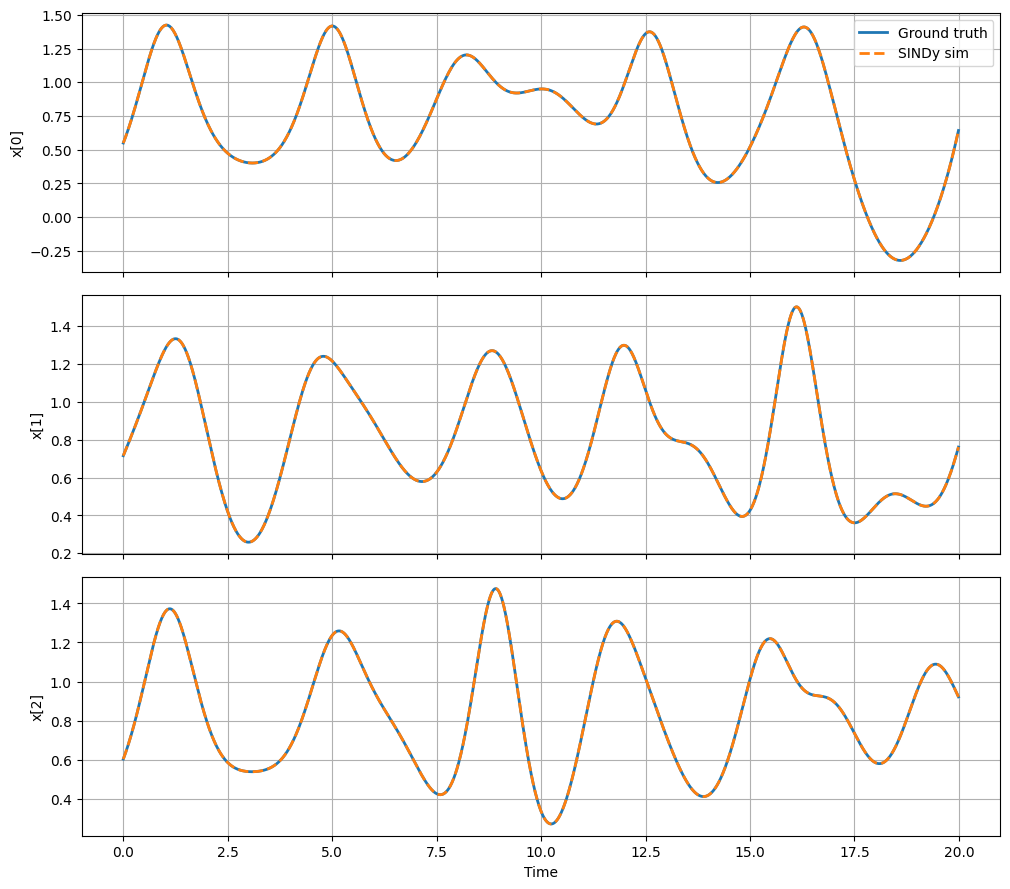

In [53]:
# Plot ground truth vs. SINDy simulation
n_plot = min(3, training_input.shape[1])
fig, axes = plt.subplots(n_plot, 1, figsize=(10, 3 * n_plot), sharex=True)
if n_plot == 1:
    axes = [axes]

for idx, ax in enumerate(axes[:n_plot]):
    ax.plot(t_eval, training_input[:, idx], label="Ground truth", linewidth=2)
    ax.plot(t_eval, sim_pred[:, idx], "--", label="SINDy sim", linewidth=2)
    ax.set_ylabel(f"x[{idx}]")

axes[-1].set_xlabel("Time")
axes[0].legend()
plt.tight_layout()
plt.show()


Run the cells again after tweaking the configuration to try new systems or optimizers.